In [1]:
#%pip install pandas==2.2.3
#%pip install git+https://github.com/pydata/pandas-datareader.git
#%pip install yfinance numpy matplotlib
#%pip install tensorflow scikit-learn 

In [2]:
import pandas as pd #importamos pandas para el manejo de datos
import numpy as np #importamos numpy para el manejo de arrays
import matplotlib.pyplot as plt #importamos matplotlib para la visualización de datos
from sklearn.preprocessing import MinMaxScaler, StandardScaler #importamos MinMaxScaler y StandardScaler para la normalización de datos
from tensorflow.keras.models import Sequential #importamos Sequential para la construcción del modelo LSTM
from tensorflow.keras.layers import LSTM, Dense, Dropout #importamos las capas necesarias para el modelo LSTM
from tensorflow.keras.optimizers import Adam, RMSprop #importamos Adam para la optimización del modelo
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau #importamos callbacks para el entrenamiento del modelo
import tensorflow as tf #importamos tensorflow para el entrenamiento del modelo
import joblib #importamos joblib para guardar el modelo entrenado 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv('../../datos_activo.csv')

#df.drop(columns=['Date'], inplace=True)  # Eliminar columna de fecha
df.head()

,Close,High,Low,Open,Volume,return,target,range,volume_change,close_ma5,close_ma20,return_vol5,return_vol20,lag_1,lag_2,lag_3,lag_6,lag_12
0,0.349069,0.349069,0.328994,0.330342,529496800,0.063927,0.012017,0.057509,2.842993,0.333159,0.326709,0.031891,0.033359,-0.023631,0.016313,0.026989,0.015965,-0.022801
1,0.353264,0.355811,0.341129,0.344574,612007200,0.012017,0.004666,0.041561,0.155828,0.339421,0.327593,0.031447,0.030456,0.063927,-0.023631,0.016313,0.017144,-0.029048
2,0.354912,0.358807,0.344425,0.349668,409976000,0.004666,-0.033347,0.040524,-0.330112,0.344275,0.327541,0.031635,0.027280,0.012017,0.063927,-0.023631,0.006085,0.011280
3,0.343077,0.359556,0.340829,0.355361,444584000,-0.033347,-0.012665,0.054584,0.084415,0.345683,0.327630,0.038117,0.026699,0.004666,0.012017,0.063927,0.026989,0.018916
4,0.338732,0.345324,0.336484,0.340829,450038400,-0.012665,-0.042459,0.026095,0.012269,0.347811,0.327683,0.036352,0.026750,-0.033347,0.004666,0.012017,0.016313,0.029031


In [4]:
def division_conjuntos(dataframe, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
    '''Función para dividir un dataframe en conjuntos de entrenamiento, validación y prueba.
    Parámetros:
    dataframe: DataFrame a dividir
    tr_size: Proporción de datos para el conjunto de entrenamiento (default=0.8)
    vl_size: Proporción de datos para el conjunto de validación (default=0.1)
    ts_size: Proporción de datos para el conjunto de prueba (default=0.1)
    Retorna:
    train: DataFrame de entrenamiento
    val: DataFrame de validación
    test: DataFrame de prueba
    '''
    N = dataframe.shape[0] # Número total de datos
    Ntrain = int(tr_size*N)  # Número de datos de entrenamiento
    Nval = int(vl_size*N)    # Número de datos de validación
    Ntst = int(ts_size*N)    # Número de datos de prueba

    # Realizar partición
    train = dataframe[0:Ntrain] # Conjunto de entrenamiento
    val = dataframe[Ntrain:Ntrain+Nval] # Conjunto de validación
    test = dataframe[Ntrain+Nval:] # Conjunto de prueba

    return train, val, test

# Prueba de la función
tr, vl, ts = division_conjuntos(df) # Dividimos el dataframe en conjuntos de entrenamiento, validación y prueba utilizando la función division_conjuntos.


In [5]:
def directional_accuracy(y_true, y_pred):
    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)
    valid = true_dir != 0
    if valid.sum() == 0:
        return 0
    return np.mean(true_dir[valid] == pred_dir[valid])

In [6]:
#col = df.columns[-4]

# Dibujar los sets de entrenamiento/validación/prueba para la covariable
#fig, ax = plt.subplots(figsize = (16,5))
#ax.plot(tr[col], label='Train')
#ax.plot(vl[col], label='Val')
#ax.plot(ts[col], label='Test')
#ax.set_title(f'Covariable: {col}')
#plt.legend();

In [7]:
INPUT_LENGTH = 40       # Días de entrada (como en el ejemplo, pero ajustado)
OUTPUT_LENGTH = 5       # Días a predecir (multistep)
N_UNITS = 128           # Neuronas (como en el ejemplo)
BATCH_SIZE = 64         # Batch size (similar al ejemplo)
EPOCHS = 150
LEARNING_RATE = 0.001  # Tasa de aprendizaje (como en el ejemplo)

In [8]:
X_tr_df = tr.drop(columns=['target'])
y_tr_df = tr['target']

X_vl_df = vl.drop(columns=['target'])
y_vl_df = vl['target']

X_ts_df = ts.drop(columns=['target'])
y_ts_df = ts['target']

def crear_dataset_supervisado_seguro(X_df, y_df, input_length, output_length):
    """
    Crea secuencias donde X contiene SOLO features (sin target)
    e Y contiene SOLO el target futuro.
    """
    X_seq, Y_seq = [], []
    X_values = X_df.values
    y_values = y_df.values
    
    for i in range(len(X_values) - input_length - output_length + 1):
        # X: solo features (NO contiene target)
        X_seq.append(X_values[i:i+input_length, :])
        # Y: target futuro
        Y_seq.append(y_values[i+input_length:i+input_length+output_length])
    
    X_seq = np.array(X_seq)
    Y_seq = np.array(Y_seq).reshape(-1, output_length, 1)
    
    return X_seq, Y_seq

# Crear secuencias (SIN leakage)
X_tr, Y_tr = crear_dataset_supervisado_seguro(X_tr_df, y_tr_df, INPUT_LENGTH, OUTPUT_LENGTH)
X_vl, Y_vl = crear_dataset_supervisado_seguro(X_vl_df, y_vl_df, INPUT_LENGTH, OUTPUT_LENGTH)
X_ts, Y_ts = crear_dataset_supervisado_seguro(X_ts_df, y_ts_df, INPUT_LENGTH, OUTPUT_LENGTH)


print(f"X_tr shape: {X_tr.shape}")  # (muestras, INPUT_LENGTH, features)
print(f"Y_tr shape: {Y_tr.shape}")  # (muestras, OUTPUT_LENGTH, 1)

X_tr shape: (4817, 40, 17)
Y_tr shape: (4817, 5, 1)


In [9]:
# El ejemplo escala todas las variables con MinMaxScaler
scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_Y = MinMaxScaler(feature_range=(-1, 1))

# Escalar X (todas las features)
X_tr_2d = X_tr.reshape(-1, X_tr.shape[-1])
X_vl_2d = X_vl.reshape(-1, X_vl.shape[-1])
X_ts_2d = X_ts.reshape(-1, X_ts.shape[-1])

scaler_X.fit(X_tr_2d)
X_tr_scaled = scaler_X.transform(X_tr_2d).reshape(X_tr.shape)
X_vl_scaled = scaler_X.transform(X_vl_2d).reshape(X_vl.shape)
X_ts_scaled = scaler_X.transform(X_ts_2d).reshape(X_ts.shape)

# Escalar Y (solo el target)
Y_tr_2d = Y_tr.reshape(-1, 1)
Y_vl_2d = Y_vl.reshape(-1, 1)
Y_ts_2d = Y_ts.reshape(-1, 1)

scaler_Y.fit(Y_tr_2d)
Y_tr_scaled = scaler_Y.transform(Y_tr_2d).reshape(Y_tr.shape)
Y_vl_scaled = scaler_Y.transform(Y_vl_2d).reshape(Y_vl.shape)
Y_ts_scaled = scaler_Y.transform(Y_ts_2d).reshape(Y_ts.shape)

print("Escalado completado")

Escalado completado


In [10]:
def root_mean_squared_error(y_true, y_pred):
    """Métrica RMSE para el entrenamiento"""
    return tf.math.sqrt(tf.math.reduce_mean(tf.square(y_pred - y_true)))

modelo = Sequential()
modelo.add(LSTM(units=N_UNITS, 
                input_shape=(INPUT_LENGTH, X_tr.shape[2]), 
                return_sequences=True,
                dropout=0.2,
                recurrent_dropout=0.2))
modelo.add(LSTM(units=N_UNITS // 2, 
                return_sequences=False,
                dropout=0.2,
                recurrent_dropout=0.2))
modelo.add(Dense(32, activation='relu'))
modelo.add(Dense(OUTPUT_LENGTH, activation='linear'))

modelo.compile(optimizer=RMSprop(learning_rate=LEARNING_RATE),
               loss='mse',
               metrics=['mae'])

modelo.summary()

c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 40, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,405 (493.77 KB)

 Trainable params: 126,405 (493.77 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True,
    verbose=1
)

historia = modelo.fit(
    X_tr_scaled, Y_tr_scaled,
    validation_data=(X_vl_scaled, Y_vl_scaled),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 0.0220 - mae: 0.1069 - val_loss: 0.0157 - val_mae: 0.0964
Epoch 2/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0196 - mae: 0.0993 - val_loss: 0.0158 - val_mae: 0.0965
Epoch 3/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0194 - mae: 0.0983 - val_loss: 0.0140 - val_mae: 0.0898
Epoch 4/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0192 - mae: 0.0978 - val_loss: 0.0137 - val_mae: 0.0885
Epoch 5/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0190 - mae: 0.0971 - val_loss: 0.0133 - val_mae: 0.0865
Epoch 6/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0191 - mae: 0.0974 - val_loss: 0.0136 - val_mae: 0.0880
Epoch 7/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0190 - mae: 0.0970 - val_loss: 0.0134 - val_mae: 0.0870
Epoch 8/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0190 - mae: 0.0970 - val_loss: 0.0132 - val_mae: 0.0862
Epoch 9/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - l

loss: 0.0710 - mae: 0.2080 - val_loss: 0.0732 - val_mae: 0.2275 - learning_rate: 5.0000e-04

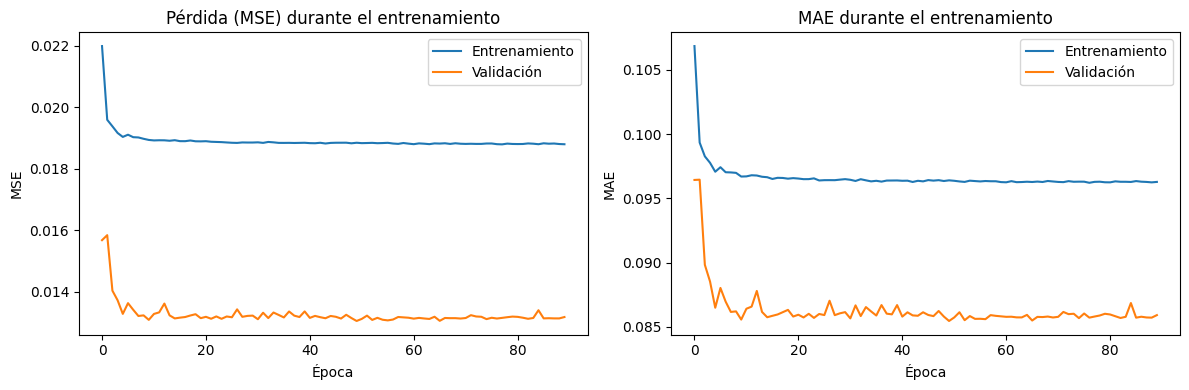

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historia.history['loss'], label='Entrenamiento')
plt.plot(historia.history['val_loss'], label='Validación')
plt.title('Pérdida (MSE) durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historia.history['mae'], label='Entrenamiento')
plt.plot(historia.history['val_mae'], label='Validación')
plt.title('MAE durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png')
plt.show()

In [13]:
# Guardar modelo y escaladores
#modelo.save('lstm_model.keras')
#joblib.dump(scaler_X, 'scaler_X.pkl')
#joblib.dump(scaler_Y, 'scaler_Y.pkl')


In [14]:
Y_pred_scaled = modelo.predict(X_ts_scaled, verbose=0)
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled.reshape(-1, 1)).reshape(-1, OUTPUT_LENGTH)
Y_true = scaler_Y.inverse_transform(Y_ts_scaled.reshape(-1, 1)).reshape(-1, OUTPUT_LENGTH)

# Aplanar para métricas
y_true_flat = Y_true.flatten()
y_pred_flat = Y_pred.flatten()

# Métricas
def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
r2 = r2_score(y_true_flat, y_pred_flat)
da = directional_accuracy(y_true_flat, y_pred_flat)

print("=== RESULTADOS LSTM ===")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²: {r2:.4f}")
print(f"Directional Accuracy: {da:.4f}")

=== RESULTADOS LSTM ===
MAE: 0.012266
RMSE: 0.017869
R²: -0.0717
Directional Accuracy: 0.4758


=== LSTM - RESULTADOS TEST ===
MAE: 0.0026
RMSE: 0.0041
R²: 0.9396
Directional Accuracy: 0.9232

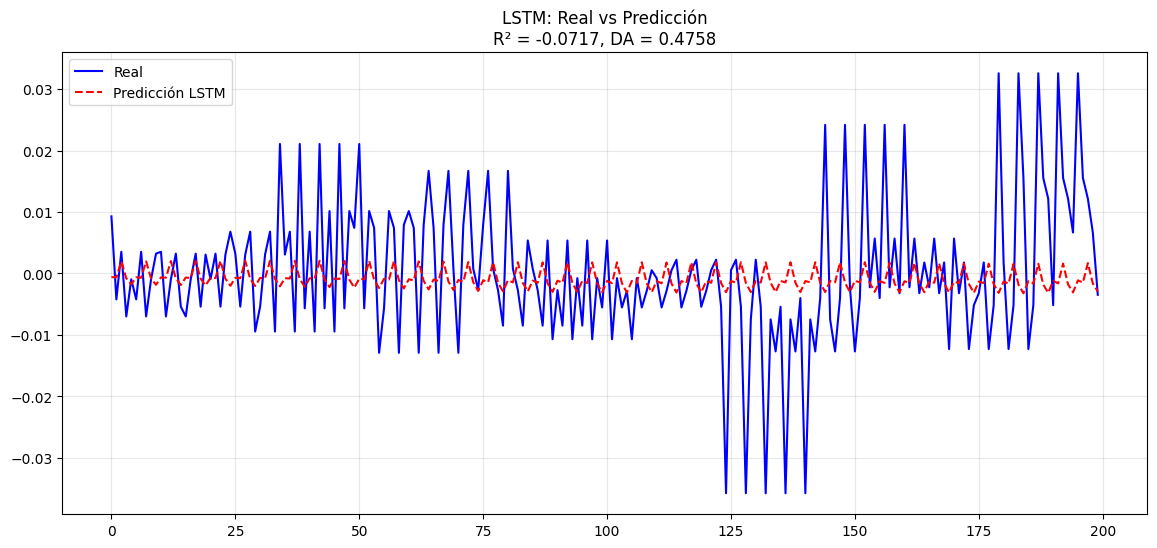

In [15]:

plt.figure(figsize=(14, 6))
n_mostrar = min(200, len(y_true_flat))
plt.plot(y_true_flat[:n_mostrar], label='Real', color='blue', linewidth=1.5)
plt.plot(y_pred_flat[:n_mostrar], label='Predicción LSTM', color='red', linestyle='--', linewidth=1.5)
plt.title(f'LSTM: Real vs Predicción\nR² = {r2:.4f}, DA = {da:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



In [16]:
def backtesting_lstm(dataframe, input_length=12, output_length=12, 
                     window_train=1000, test_size=252, step=63, 
                     n_units=64, dropout_rate=0.1, learning_rate=0.001,
                     batch_size=32, epochs=100):
    """
    Realiza backtesting con ventana deslizante para LSTM.
    
    Parámetros:
    -----------
    dataframe : DataFrame
        Dataset completo ordenado cronológicamente
    input_length : int
        Ventana de entrada (días)
    output_length : int
        Ventana de salida a predecir (días)
    window_train : int
        Tamaño de la ventana de entrenamiento (días)
    test_size : int
        Tamaño de la ventana de prueba (días)
    step : int
        Número de días que se desplaza la ventana en cada iteración
    n_units : int
        Número de neuronas LSTM
    dropout_rate : float
        Tasa de dropout
    learning_rate : float
        Tasa de aprendizaje
    batch_size : int
        Tamaño del batch
    epochs : int
        Máximo de épocas
        
    Retorna:
    --------
    resultados : DataFrame
        DataFrame con las métricas de cada iteración
    media_metricas : dict
        Diccionario con las métricas promedio
    """
    
    resultados = []
    
    # Calcular número total de iteraciones
    n_iterations = (len(dataframe) - window_train - test_size) // step + 1
    print(f"Total iteraciones backtesting: {n_iterations}")
    
    for i, start in enumerate(range(0, len(dataframe) - window_train - test_size, step)):
        print(f"\n--- Iteración {i+1}/{n_iterations} ---")
        print(f"Ventana: índices {start} a {start + window_train + test_size}")
        
        train_end = start + window_train
        test_end = train_end + test_size
        
        # Obtenemos los datos de entrenamiento y prueba
        train = dataframe.iloc[start:train_end]
        test = dataframe.iloc[train_end:test_end]
        
        # Separamos características (X) y variable objetivo (y)
        X_train = train.drop(columns=['target'])
        y_train = train['target']
        
        X_test = test.drop(columns=['target'])
        y_test = test['target']
        
        # Crear secuencias
        def crear_secuencias_bt(X, y, input_len, output_len):
            X_seq, y_seq = [], []
            values_X = X.values
            values_y = y.values
            
            for j in range(len(values_X) - input_len - output_len + 1):
                X_seq.append(values_X[j:j+input_len, :])
                y_seq.append(values_y[j+input_len:j+input_len+output_len])
            
            if len(X_seq) == 0:
                return np.array([]), np.array([])
            
            X_seq = np.array(X_seq)
            y_seq = np.array(y_seq).reshape(-1, output_len, 1)
            return X_seq, y_seq
        
        X_tr_seq, Y_tr_seq = crear_secuencias_bt(X_train, y_train, input_length, output_length)
        X_ts_seq, Y_ts_seq = crear_secuencias_bt(X_test, y_test, input_length, output_length)
        
        if len(X_tr_seq) == 0 or len(X_ts_seq) == 0:
            print(f"⚠️ Iteración {i+1}: No hay suficientes muestras para crear secuencias")
            continue
        
        # Escalar datos
        scaler_X = MinMaxScaler(feature_range=(-1, 1))
        scaler_Y = MinMaxScaler(feature_range=(-1, 1))
        
        X_reshaped = X_tr_seq.reshape(-1, X_tr_seq.shape[-1])
        scaler_X.fit(X_reshaped)
        X_tr_scaled = scaler_X.transform(X_reshaped).reshape(X_tr_seq.shape)
        
        X_ts_reshaped = X_ts_seq.reshape(-1, X_ts_seq.shape[-1])
        X_ts_scaled = scaler_X.transform(X_ts_reshaped).reshape(X_ts_seq.shape)
        
        Y_reshaped = Y_tr_seq.reshape(-1, Y_tr_seq.shape[-1])
        scaler_Y.fit(Y_reshaped)
        Y_tr_scaled = scaler_Y.transform(Y_reshaped).reshape(Y_tr_seq.shape)
        
        # Construir modelo LSTM
        tf.random.set_seed(42)
        np.random.seed(42)
        
        model = Sequential()
        model.add(LSTM(
            units=n_units,
            input_shape=(input_length, X_tr_seq.shape[2]),
            return_sequences=False,
            dropout=dropout_rate,
            recurrent_dropout=dropout_rate
        ))
        model.add(Dense(output_length, activation='linear'))
        
        model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='mse',
            metrics=['mae']
        )
        
        early_stop = EarlyStopping(
            monitor='loss',
            patience=20,
            restore_best_weights=True,
            verbose=0
        )
        
        # Entrenar
        model.fit(
            X_tr_scaled, Y_tr_scaled,
            epochs=min(epochs, 100),
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0
        )
        
        # Predecir
        Y_pred_scaled = model.predict(X_ts_scaled, verbose=0)
        Y_pred = scaler_Y.inverse_transform(Y_pred_scaled.reshape(-1, output_length))
        Y_true = scaler_Y.inverse_transform(Y_ts_seq.reshape(-1, output_length))
        
        # Métricas
        y_true_flat = Y_true.flatten()
        y_pred_flat = Y_pred.flatten()
        
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
        r2 = r2_score(y_true_flat, y_pred_flat)
        da = directional_accuracy(y_true_flat, y_pred_flat)
        
        resultados.append({
            'iteracion': i + 1,
            'train_inicio': start,
            'train_fin': train_end,
            'test_inicio': train_end,
            'test_fin': test_end,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'DA': da
        })
        
        print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}, DA: {da:.4f}")
    
    if len(resultados) == 0:
        print("❌ No se completó ninguna iteración de backtesting")
        return pd.DataFrame(), {}
    
    df_resultados = pd.DataFrame(resultados)
    
    media_metricas = {
        'MAE_mean': df_resultados['MAE'].mean(),
        'MAE_std': df_resultados['MAE'].std(),
        'RMSE_mean': df_resultados['RMSE'].mean(),
        'RMSE_std': df_resultados['RMSE'].std(),
        'R2_mean': df_resultados['R2'].mean(),
        'R2_std': df_resultados['R2'].std(),
        'DA_mean': df_resultados['DA'].mean(),
        'DA_std': df_resultados['DA'].std()
    }
    
    print("\n" + "="*60)
    print("=== RESULTADOS BACKTESTING LSTM ===")
    print(f"MAE medio: {media_metricas['MAE_mean']:.4f} (±{media_metricas['MAE_std']:.4f})")
    print(f"RMSE medio: {media_metricas['RMSE_mean']:.4f} (±{media_metricas['RMSE_std']:.4f})")
    print(f"R² medio: {media_metricas['R2_mean']:.4f} (±{media_metricas['R2_std']:.4f})")
    print(f"DA medio: {media_metricas['DA_mean']:.4f} (±{media_metricas['DA_std']:.4f})")
    print("="*60)
    
    return df_resultados, media_metricas


In [17]:
resultados_bt, metricas_bt = backtesting_lstm(
    dataframe=df,
    input_length=20,        # 20 días de entrada (≈1 mes)
    output_length=5,        # Predecir 5 días
    window_train=500,       # 500 días de entrenamiento (≈2 años)
    test_size=252,          # 252 días de prueba (≈1 año)
    step=63,                # Desplazar 63 días (~3 meses)
    n_units=64,
    dropout_rate=0.2,
    learning_rate=0.001,
    batch_size=32,
    epochs=50
)

Total iteraciones backtesting: 85

--- Iteración 1/85 ---
Ventana: índices 0 a 752


c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 0.0140, RMSE: 0.0180, R²: -26.8954, DA: 0.8044

--- Iteración 2/85 ---
Ventana: índices 63 a 815


c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 

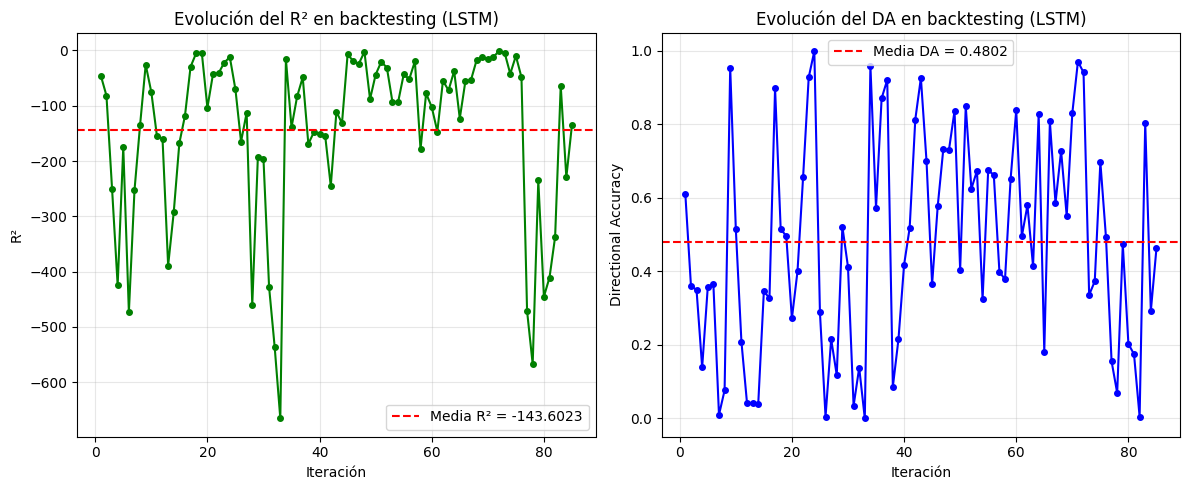

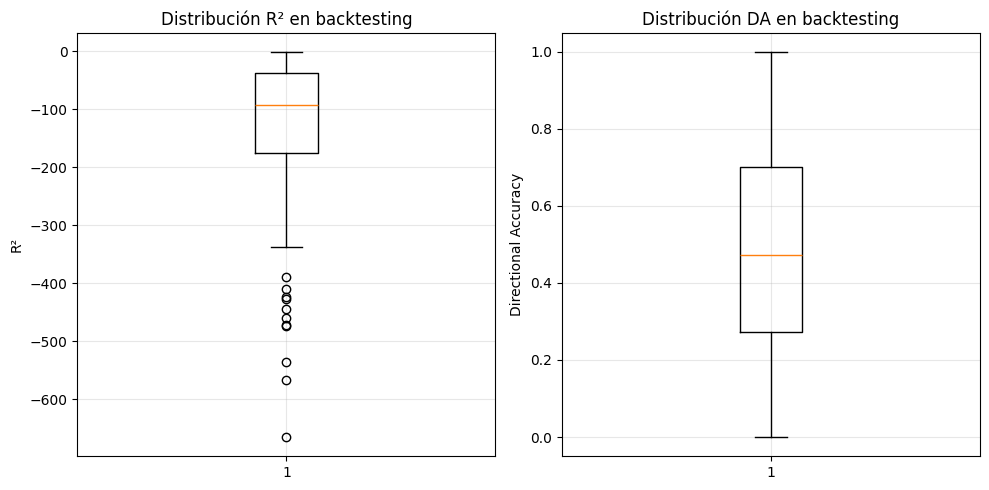

In [ ]:
if len(resultados_bt) > 0:
    plt.figure(figsize=(12, 5))
    
    # Evolución del R²
    plt.subplot(1, 2, 1)
    plt.plot(resultados_bt['iteracion'], resultados_bt['R2'], 'o-', color='green', markersize=4)
    plt.axhline(y=metricas_bt['R2_mean'], color='red', linestyle='--', 
                label=f'Media R² = {metricas_bt["R2_mean"]:.4f}')
    plt.xlabel('Iteración')
    plt.ylabel('R²')
    plt.title('Evolución del R² en backtesting (LSTM)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Evolución del DA
    plt.subplot(1, 2, 2)
    plt.plot(resultados_bt['iteracion'], resultados_bt['DA'], 'o-', color='blue', markersize=4)
    plt.axhline(y=metricas_bt['DA_mean'], color='red', linestyle='--', 
                label=f'Media DA = {metricas_bt["DA_mean"]:.4f}')
    plt.xlabel('Iteración')
    plt.ylabel('Directional Accuracy')
    plt.title('Evolución del DA en backtesting (LSTM)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('lstm_backtesting_evolucion.png', dpi=150)
    plt.show()
    
    # Boxplot de métricas
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.boxplot(resultados_bt['R2'])
    plt.title('Distribución R² en backtesting')
    plt.ylabel('R²')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.boxplot(resultados_bt['DA'])
    plt.title('Distribución DA en backtesting')
    plt.ylabel('Directional Accuracy')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('lstm_backtesting_boxplot.png', dpi=150)
    plt.show()
else:
    print("No hay resultados para graficar")